# seqKAN_analise
Notebook derivado de `seqKAN_experimentosNEW.ipynb` contendo apenas setup de dados (`dl`) e blocos de análise/explainability.
Blocos de treinamento foram removidos.


**Ordem sugerida:** setup -> credencial COGNITE -> DataLoader (`dl`) -> checkpoint loader -> benchmark/explainability.


In [5]:
import sys
from pathlib import Path

repo_root = Path('/home/ferna/CPE727-2025-03/Seminarios/6 - RNN')
sys.path.insert(0, str(repo_root))


### 1. Configuração do Ambiente

In [ ]:
#!pip install "cognite-sdk[pandas]" matplotlib seaborn tensorflow plotly -q

import os
from datetime import datetime
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from IPython.display import display
from sklearn.preprocessing import RobustScaler
from statsmodels.tsa.stattools import acf
from industrial_ts.dataloader import DataLoader
import json
from getpass import getpass
#import tensorflow as tf
#from tensorflow import keras

print("Bibliotecas importadas com sucesso!")






Updated: UnsupervisedStateSegmenter now supports multi-channel (multivariate) series.

Bibliotecas importadas com sucesso!


/home/ferna/fe/lib/python3.12/site-packages/ipykernel/ipkernel.py:772: UserWarning: You are using version='7.83.1' of the SDK, however version='7.92.0' is available. To suppress this warning, either upgrade or do the following:
>>> from cognite.client.config import global_config
>>> global_config.disable_pypi_version_check = True
  _threading_Thread_run(self)


In [7]:
os.environ['COGNITE_CLIENT_SECRET'] = getpass("Enter COGNITE_CLIENT")






### 2. Ativar o DataLoader

In [8]:
import importlib
import sys
importlib.reload(sys.modules['industrial_ts.dataloader'])
from industrial_ts.dataloader import DataLoader
dl = DataLoader()
dl.add_segments(segments=3, window=10, step=10, series=[
    'PH (CBM) 1st Stg ActCompr Poly Head',
    'PH (CBM) 1st Stage ActShaft Power',
    'PH (CBM) 1st Stg ActCompr Poly Head',
    'PH (CBM) 1st Stage ActPress Ratio'  
], path="segmenter_model_10.pkl"
)
#dl.segmenter.save("segmenter_model_10.pkl")








Buscando dados para as 12 séries temporais encontradas.


### 10 Pós-processamento

In [9]:
for i in [2]:
    dl.df['states'].replace(i, 1, inplace=True) # Merge states 1 and 2







/tmp/ipykernel_26377/4230046523.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dl.df['states'].replace(i, 1, inplace=True) # Merge states 1 and 2


In [10]:
dl.add_time_to_change_state_timestamp()






# --- CHECKPOINT_LOADER_V2

In [11]:
# --- CHECKPOINT_LOADER_V2 (nao sobrescreve suas celulas) ---
import torch
from industrial_ts.seqKAN import TSDF_seqKANSeq
from industrial_ts.gru import TSDF_GRU

# 1) Preencha os caminhos abaixo
SEQKAN_CKPT_PATH = r"/home/ferna/CPE727-2025-03/Seminarios/6 - RNN/TSDF_seqKANSeq_tsdf_seqKANseq_H24_g8_ge0.2_c-3.0_3.0_radam_kanout_best.pt"
GRU_CKPT_PATH    = r"/home/ferna/CPE727-2025-03/Seminarios/6 - RNN/TSDF_GRU_final_rebuild_tsdf_gru_H24_c-3.0_3.0_radam_best_champion.pt"

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 2) Se precisar, ajuste manualmente. Se None, tenta inferir do state_dict.
SEQKAN_CFG = {
    'in_channels': 11,
    'hidden_dim': 24,
    'kan_params': {
        'cell':   {'grid': 8, 'k': 3, 'grid_range': (-3.0, 3.0), 'grid_eps': 0.2},
        'output': {'grid': 8, 'k': 3, 'grid_range': (-3.0, 3.0), 'grid_eps': 0.2},
    },
    'lam': [1.0, 0.0, 0.0, 0.0, 0.0, 0.0],
    'x_min': -3.0,
    'x_max': 3.0,
}

GRU_CFG = {
    'in_channels': 11,
    'hidden_dim': 24,
    'status_dim': 0,
    'lam': [1.0, 0.0, 0.0, 0.0, 0.0, 0.0],
    'bi_gru': False,
    'bi_method': 'concat',
    'bi_coupled': False,
    'x_min': -3.0,
    'x_max': 3.0,
}


def _unwrap_state_dict(ckpt_obj):
    if isinstance(ckpt_obj, dict) and 'state_dict' in ckpt_obj:
        return ckpt_obj['state_dict']
    return ckpt_obj


def _infer_seqkan_dims(sd):
    in_ch = None
    hid = None
    for k, v in sd.items():
        if k.endswith('seqKAN.kan_encoder.act_fun.0.grid') and torch.is_tensor(v):
            in_ch = int(v.shape[0])
        if k.endswith('seqKAN.kan_out.act_fun.0.grid') and torch.is_tensor(v):
            hid = int(v.shape[0])
    if in_ch is None:
        for k, v in sd.items():
            if k.endswith('mask_proj.weight') and torch.is_tensor(v) and v.ndim == 2:
                in_ch = int(v.shape[1])
                break
    return in_ch, hid


def _infer_gru_dims(sd):
    # encoder.0.weight: (hidden_dim, in_channels*2)
    for k, v in sd.items():
        if k.endswith('encoder.0.weight') and torch.is_tensor(v) and v.ndim == 2:
            return int(v.shape[1] // 2), int(v.shape[0])
    return None, None


# 3) Carregamento seqKAN
if SEQKAN_CKPT_PATH and '/caminho/para/' not in SEQKAN_CKPT_PATH:
    ckpt_seq = torch.load(SEQKAN_CKPT_PATH, map_location='cpu')
    sd_seq = _unwrap_state_dict(ckpt_seq)

    inf_in, inf_hid = _infer_seqkan_dims(sd_seq)
    in_ch = SEQKAN_CFG['in_channels'] if SEQKAN_CFG['in_channels'] is not None else inf_in
    hid = SEQKAN_CFG['hidden_dim'] if SEQKAN_CFG['hidden_dim'] is not None else inf_hid

    if in_ch is None or hid is None:
        raise ValueError('seqKAN: nao consegui inferir dimensoes. Preencha SEQKAN_CFG[in_channels] e [hidden_dim].')

    seqkan_model = TSDF_seqKANSeq(
        in_channels=in_ch,
        hidden_dim=hid,
        kan_params=SEQKAN_CFG['kan_params'],
        lam=SEQKAN_CFG['lam'],
        log_likelihood=False,
        x_min=SEQKAN_CFG['x_min'],
        x_max=SEQKAN_CFG['x_max'],
    ).to(DEVICE)

    miss, unexp = seqkan_model.load_state_dict(sd_seq, strict=False)
    seqkan_model.eval()
    print(f'[seqKAN] ok: {SEQKAN_CKPT_PATH}')
    print(f'[seqKAN] in_channels={in_ch}, hidden_dim={hid}, missing={len(miss)}, unexpected={len(unexp)}')
else:
    print('[seqKAN] caminho nao preenchido.')


# 4) Carregamento GRU
if GRU_CKPT_PATH and '/caminho/para/' not in GRU_CKPT_PATH:
    ckpt_gru = torch.load(GRU_CKPT_PATH, map_location='cpu')
    sd_gru = _unwrap_state_dict(ckpt_gru)

    inf_in, inf_hid = _infer_gru_dims(sd_gru)
    in_ch = GRU_CFG['in_channels'] if GRU_CFG['in_channels'] is not None else inf_in
    hid = GRU_CFG['hidden_dim'] if GRU_CFG['hidden_dim'] is not None else inf_hid

    if in_ch is None or hid is None:
        raise ValueError('GRU: nao consegui inferir dimensoes. Preencha GRU_CFG[in_channels] e [hidden_dim].')

    # Se o config divergir do checkpoint, prioriza checkpoint para evitar size mismatch.
    if inf_in is not None and inf_hid is not None and (in_ch != inf_in or hid != inf_hid):
        print(f"[GRU][warn] cfg (in={in_ch}, hid={hid}) difere do ckpt (in={inf_in}, hid={inf_hid}). Usando dimensoes do ckpt.")
        in_ch, hid = inf_in, inf_hid

    gru_model = TSDF_GRU(
        in_channels=in_ch,
        hidden_dim=hid,
        status_dim=GRU_CFG['status_dim'],
        lam=GRU_CFG['lam'],
        bi_gru=GRU_CFG['bi_gru'],
        bi_method=GRU_CFG['bi_method'],
        bi_coupled=GRU_CFG['bi_coupled'],
        log_likelihood=False,
        x_min=GRU_CFG['x_min'],
        x_max=GRU_CFG['x_max'],
    ).to(DEVICE)

    miss, unexp = gru_model.load_state_dict(sd_gru, strict=False)
    gru_model.eval()
    print(f'[GRU] ok: {GRU_CKPT_PATH}')
    print(f'[GRU] in_channels={in_ch}, hidden_dim={hid}, missing={len(miss)}, unexpected={len(unexp)}')
else:
    print('[GRU] caminho nao preenchido.')

print('Modelos disponiveis no notebook: seqkan_model e gru_model')



[seqKAN] ok: /home/ferna/CPE727-2025-03/Seminarios/6 - RNN/TSDF_seqKANSeq_tsdf_seqKANseq_H24_g8_ge0.2_c-3.0_3.0_radam_kanout_best.pt
[seqKAN] in_channels=11, hidden_dim=24, missing=0, unexpected=0
[GRU] ok: /home/ferna/CPE727-2025-03/Seminarios/6 - RNN/TSDF_GRU_final_rebuild_tsdf_gru_H24_c-3.0_3.0_radam_best_champion.pt
[GRU] in_channels=11, hidden_dim=24, missing=4, unexpected=0
Modelos disponiveis no notebook: seqkan_model e gru_model


/home/ferna/fe/lib/python3.12/site-packages/torch/nn/modules/transformer.py:382: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


In [12]:
# --- EXPLAINABILITY_V2 (importado de explainability_v2.py) ---
import importlib
import explainability_v2 as exv2
importlib.reload(exv2)

# Exporta funções esperadas pelas células de resultado
explainability_benchmark_v2 = exv2.explainability_benchmark_v2
_make_eval_batch = exv2._make_eval_batch

print('OK: explainability_v2.py carregado')



OK: explainability_v2.py carregado


## RUNBOOK (ordem de execução limpa)

Execute **somente** nesta ordem:

1. `# --- CHECKPOINT_LOADER_V2 (nao sobrescreve suas celulas) ---`
2. `# --- EXPLAINABILITY_V2 (importado de explainability_v2.py) ---`
3. `STEP-AD-RULES` (célula abaixo, com índices já ajustados)
4. `STEP-RUN-BENCHMARK-V2` (célula abaixo, executa e salva CSVs)

Ignore as células antigas de benchmark anteriores a esta seção.


In [13]:
# STEP-AD-RULES (ajustado para suas features atuais)
# 0 PH (CBM) 1st Stage ExpPress Ratio
# 2 PH (CBM) 1st Stage ActShaft Power
# 8 PH (CBM) 1st Stage ExpShaft Power
# 9 PH (CBM) 1st Stage ActPress Ratio

ad_rules = [
    {
        'type': 'sign_consistency',
        'feature': 0,
        'output': 2,
        'v_lo': -1.0,
        'v_hi': 1.0,
        'expected': 'positive',
        'note': 'ExpPress Ratio -> ActShaft Power',
    },
    {
        'type': 'monotonic',
        'feature': 0,
        'output': 9,
        'expected': 'increasing',
        'vmin': -3.0,
        'vmax': 3.0,
        'threshold': 0.8,
        'n': 50,
        'note': 'ExpPress Ratio -> ActPress Ratio',
    },
    {
        'type': 'saturation',
        'feature': 0,
        'output': 2,
        'vmin': -3.0,
        'vmax': 3.0,
        'sat_after': 1.5,
        'max_ratio': 0.35,
        'n': 60,
        'note': 'Saturation of power at high pressure ratio',
    },
    {
        'type': 'sign_consistency',
        'feature': 8,
        'output': 2,
        'v_lo': -1.0,
        'v_hi': 1.0,
        'expected': 'positive',
        'note': 'ExpShaft Power -> ActShaft Power',
    },
]

print('ad_rules prontas:', len(ad_rules))
for r in ad_rules:
    print('-', r['type'], '| f', r['feature'], '-> out', r['output'], '|', r.get('note',''))



ad_rules prontas: 4
- sign_consistency | f 0 -> out 2 | ExpPress Ratio -> ActShaft Power
- monotonic | f 0 -> out 9 | ExpPress Ratio -> ActPress Ratio
- saturation | f 0 -> out 2 | Saturation of power at high pressure ratio
- sign_consistency | f 8 -> out 2 | ExpShaft Power -> ActShaft Power


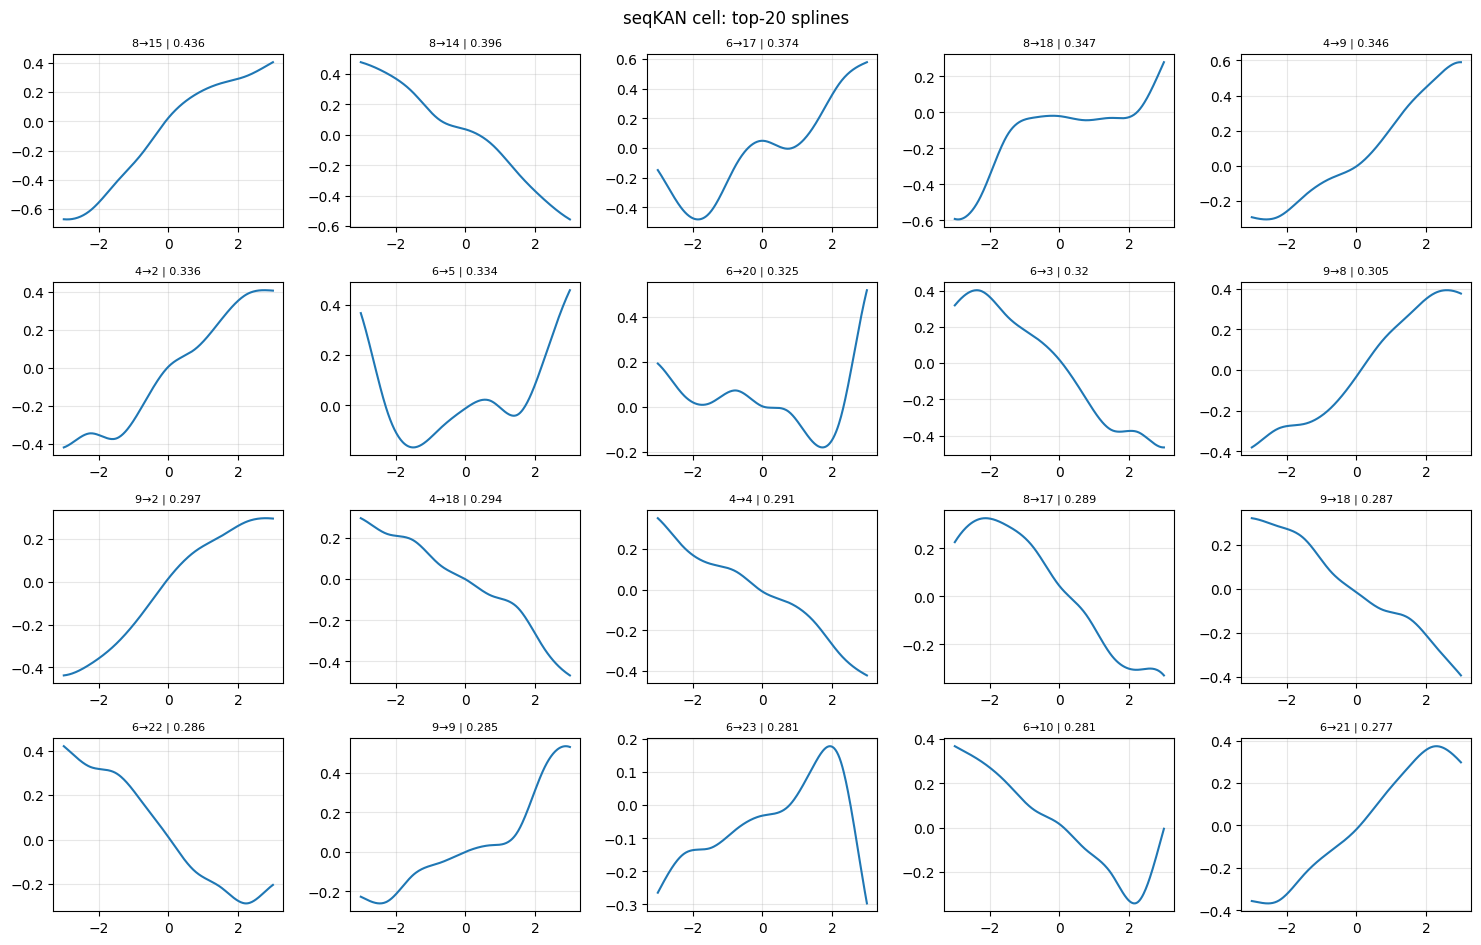

[TF] plot de spline da saída indisponível (kan_out=Linear).


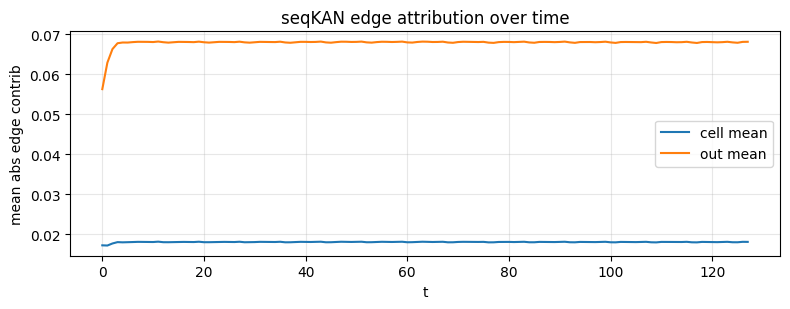

,model,TF_core_claim,TF_topk_mass_ratio,EA_method,EA_spearman_mean,EA_spearman_std,SE_seqkan_sparsity_eps,SE_gru_compress_q90,SE_gru_weights_active_frac_eps,SE_gru_hidden_active_frac_eps,AD_pass_rate,AD_rules_n
0,seqKAN,1.0,0.137532,gradxinput,0.500684,0.000559,0.282143,NaN,NaN,NaN,0.25,4
1,GRU,0.0,NaN,gradxinput,0.500684,0.000559,NaN,0.900019,0.915861,1.0,0.50,4


,EA_method,seqKAN_spearman_mean,seqKAN_spearman_std,GRU_spearman_mean,GRU_spearman_std,delta_seq_minus_gru
0,permutation_window,0.915891,0.114157,0.795261,0.120796,0.120630
1,ig,1.000000,0.000000,0.999394,0.002268,0.000606
2,gradxinput,0.500684,0.000559,0.500684,0.000559,0.000000


,feature,importance_mean,importance_std,model
0,8,2.55000,0.292217,seqKAN
1,2,2.02500,0.441234,seqKAN
2,7,0.36250,0.061237,seqKAN
3,3,0.28750,0.082443,seqKAN
4,1,0.11250,0.057960,seqKAN
5,10,0.00625,0.023385,seqKAN
6,5,-0.20000,0.105697,seqKAN
7,0,-0.99375,0.301299,seqKAN
8,9,-1.42500,0.179626,seqKAN
9,4,-2.36875,0.472030,seqKAN


OK. CSVs salvos em: /home/ferna/CPE727-2025-03/Seminarios/6 - RNN/seqKAN_results


In [14]:
# STEP-RUN-BENCHMARK-V2
import torch

if 'explainability_benchmark_v2' not in globals():
    raise ValueError('Função explainability_benchmark_v2 não encontrada. Rode a célula EXPLAINABILITY_V2 antes.')

seq_model = globals().get('seqkan_model', globals().get('model_tsdf_seqkanseq', None))
gru_model_local = globals().get('gru_model', globals().get('model_tsdf_gru', None))
if seq_model is None:
    raise ValueError('seqkan_model não encontrado. Rode CHECKPOINT_LOADER_V2.')
if gru_model_local is None:
    raise ValueError('gru_model não encontrado. Rode CHECKPOINT_LOADER_V2.')
if 'dl' not in globals():
    raise ValueError('dl não encontrado. Rode as células do DataLoader.')

if 'feature_cols' not in globals() or feature_cols is None:
    feature_cols = list(dl.df.columns[:-3])

# batch de avaliação
x_eval, ts_eval, m_eval = _make_eval_batch(
    seq_model,
    dl.df,
    feature_cols,
    timestamp_col='index',
    window_size=128,
    window_step=8,
    max_windows=256,
)

# device consistente
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
seq_model = seq_model.to(device).eval()
gru_model_local = gru_model_local.to(device).eval()
x_eval = x_eval.to(device)
ts_eval = ts_eval.to(device)
m_eval = m_eval.to(device)

# executa benchmark v2
art = explainability_benchmark_v2(
    seqkan_model=seq_model,
    gru_model=gru_model_local,
    x=x_eval,
    ts=ts_eval,
    m=m_eval,
    topk=20,
    ea_method='gradxinput',
    ea_extra_methods=('ig', 'permutation_window'),
    ea_noise_pcts=(0.005, 0.01, 0.02),
    ea_n_seeds=5,
    ea_windows_per_seed=32,
    se_eps_frac=0.01,
    ad_rules=ad_rules,
    compute_seqkan_edge_time=True,
    edge_time_max_windows=64,
    make_plots=True,
)

display(art['df_main'])
display(art['df_ea_compare'].head(10))
display(art['df_perm_window_summary'].head(20))

out_dir = '/home/ferna/CPE727-2025-03/Seminarios/6 - RNN/seqKAN_results'
art['df_main'].to_csv(f"{out_dir}/explainability_v2_main.csv", index=False)
art['df_top_edges_cell'].to_csv(f"{out_dir}/explainability_v2_top_edges_cell.csv", index=False)
art['df_top_edges_out'].to_csv(f"{out_dir}/explainability_v2_top_edges_out.csv", index=False)
if not art['ad_seq_details'].empty:
    art['ad_seq_details'].to_csv(f"{out_dir}/explainability_v2_ad_seqkan_details.csv", index=False)
if not art['ad_gru_details'].empty:
    art['ad_gru_details'].to_csv(f"{out_dir}/explainability_v2_ad_gru_details.csv", index=False)
if not art['df_ea_compare'].empty:
    art['df_ea_compare'].to_csv(f"{out_dir}/explainability_v2_ea_compare.csv", index=False)
if not art['df_perm_window_summary'].empty:
    art['df_perm_window_summary'].to_csv(f"{out_dir}/explainability_v2_perm_window_summary.csv", index=False)
if not art['df_seqkan_edge_time'].empty:
    art['df_seqkan_edge_time'].to_csv(f"{out_dir}/explainability_v2_seqkan_edge_time.csv", index=False)

print('OK. CSVs salvos em:', out_dir)




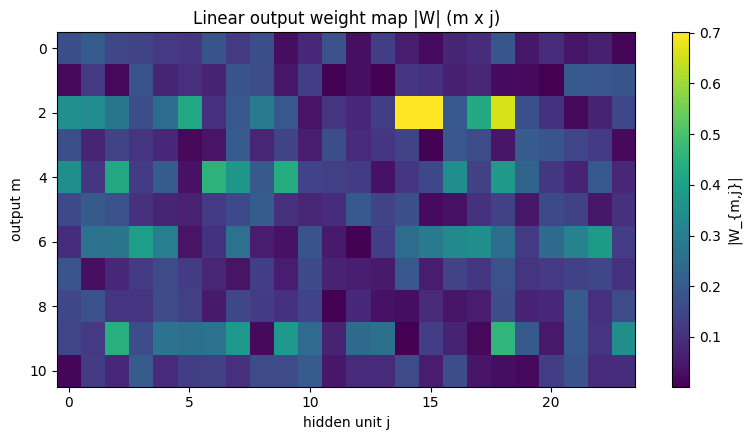

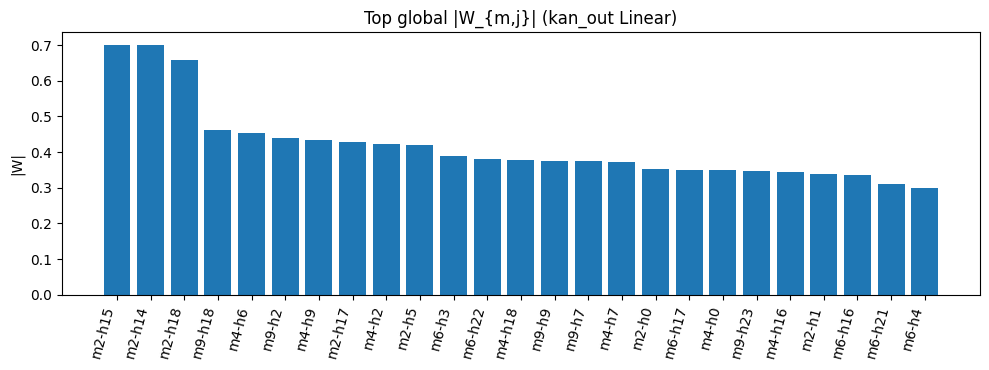

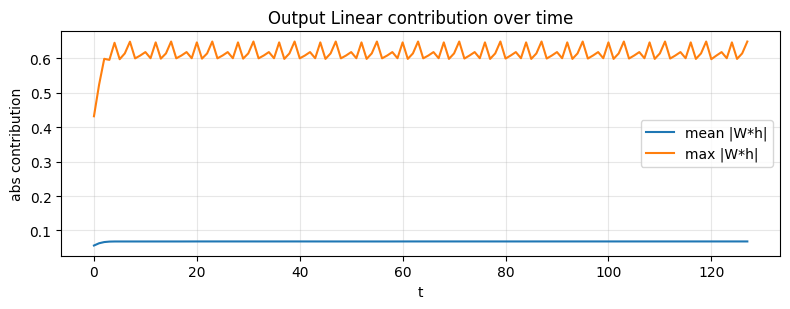

,output_m,rank,hidden_j,abs_w
0,0,1,1,0.203954
1,0,2,18,0.189156
2,0,3,6,0.184215
3,0,4,11,0.174479
4,0,5,0,0.169818
5,0,6,8,0.169074
6,0,7,2,0.149945
7,0,8,3,0.144276
8,0,9,13,0.129172
9,0,10,7,0.120123


,t,mean_abs_wh,max_abs_wh
0,0,0.056238,0.431729
1,1,0.062822,0.523508
2,2,0.066294,0.598589
3,3,0.067621,0.595526
4,4,0.067973,0.645210
5,5,0.067957,0.597480
6,6,0.068112,0.614320
7,7,0.068129,0.648389
8,8,0.068028,0.599801
9,9,0.068009,0.608170


,hidden_j,mean_abs_w,max_abs_w,n_outputs,n_cell_edges_seen,top_i_in,top_cell_scores
0,18,0.248978,0.657876,10,3,"8,4,9","0.3467,0.2936,0.2869"
1,2,0.214823,0.440350,10,2,"4,9","0.3365,0.2966"
2,14,0.211797,0.698828,9,1,8,0.3964
3,7,0.211186,0.374949,10,0,,
4,15,0.196331,0.700640,8,1,8,0.4364
5,9,0.194778,0.434835,8,2,"4,9","0.3459,0.2845"
6,0,0.179481,0.351994,10,0,,
7,16,0.175928,0.344090,9,0,,
8,21,0.174114,0.311804,9,1,6,0.2774
9,1,0.172848,0.338235,10,0,,


Saved linear-out explainability CSVs in: /home/ferna/CPE727-2025-03/Seminarios/6 - RNN/seqKAN_results


In [12]:
# STEP-LINEAR-OUT-EXPLAIN (bloco adicional no final)
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

# Usa modelos/artefatos já carregados no notebook
seq_model = globals().get('seqkan_model', globals().get('model_tsdf_seqkanseq', None))
if seq_model is None:
    raise ValueError('seqKAN não encontrado em memória (seqkan_model/model_tsdf_seqkanseq).')

if 'x_eval' not in globals() or 'ts_eval' not in globals() or 'm_eval' not in globals():
    raise ValueError('x_eval/ts_eval/m_eval não encontrados. Rode o bloco do benchmark antes.')

out_mod = seq_model.seqKAN.kan_out
if not isinstance(out_mod, torch.nn.Linear):
    print(f"[Linear-OUT] kan_out={type(out_mod).__name__}; este bloco é para saída Linear.")
else:
    # W: (out, hidden) -> (hidden, out)
    W = out_mod.weight.detach().cpu().numpy().T
    absW = np.abs(W)
    H, M = absW.shape

    # 1) Top-k |W_{m,j}| por saída m
    topk = 20
    rows = []
    for m in range(M):
        col = absW[:, m]
        kk = min(topk, H)
        idx = np.argsort(-col)[:kk]
        for r, j in enumerate(idx, start=1):
            rows.append({'output_m': int(m), 'rank': int(r), 'hidden_j': int(j), 'abs_w': float(col[j])})
    df_top_out_linear = pd.DataFrame(rows)

    # 2) Série temporal: média de |W_{m,j} * h_{t,j}|
    x, ts, msk = x_eval, ts_eval, m_eval
    dev = next(seq_model.parameters()).device
    x, ts, msk = x.to(dev), ts.to(dev), msk.to(dev)

    seq = seq_model.seqKAN
    hs = getattr(seq, 'hidden_size', None)
    if hs is None:
        hs = getattr(seq, 'hidden_dim', None)
    if hs is None:
        raise AttributeError('seqKAN sem hidden_size/hidden_dim')
    hs = int(hs)
    B, T, _ = x.shape
    h = torch.zeros(B, hs, device=dev, dtype=x.dtype)
    mask_z = seq.mask_proj((1 - msk))

    W_t = out_mod.weight.T  # (hidden, out)
    rec = []
    with torch.no_grad():
        for t in range(T):
            x_t = x[:, t, :]
            m_t = mask_z[:, t, :] * h
            if hasattr(seq, 'kan_encoder'):
                try:
                    z_t = seq.kan_encoder(x_t)
                    h_in = torch.cat([z_t, h, m_t], dim=-1)
                except Exception:
                    h_in = torch.cat([x_t, h, m_t], dim=-1)
            else:
                h_in = torch.cat([x_t, h, m_t], dim=-1)

            h = seq.kan_cell(h_in)
            contrib = (h[:, :, None] * W_t[None, :, :]).abs()  # (B, hidden, out)

            rec.append({
                't': int(t),
                'mean_abs_wh': float(contrib.mean().item()),
                'max_abs_wh': float(contrib.max().item()),
            })

    df_out_contrib_time = pd.DataFrame(rec)

    # 3) Mapa |W| (m x j)
    plt.figure(figsize=(8, 4.5))
    plt.imshow(absW.T, aspect='auto', interpolation='nearest')
    plt.colorbar(label='|W_{m,j}|')
    plt.xlabel('hidden unit j')
    plt.ylabel('output m')
    plt.title('Linear output weight map |W| (m x j)')
    plt.tight_layout()
    plt.show()

    # Barplot top-k agregado (global)
    flat = []
    for m in range(M):
        for j in range(H):
            flat.append((m, j, absW[j, m]))
    flat.sort(key=lambda z: z[2], reverse=True)
    flat = flat[:min(25, len(flat))]

    labels = [f"m{m}-h{j}" for m, j, _ in flat]
    vals = [v for _, _, v in flat]

    plt.figure(figsize=(10, 3.8))
    plt.bar(np.arange(len(vals)), vals)
    plt.xticks(np.arange(len(vals)), labels, rotation=75, ha='right')
    plt.ylabel('|W|')
    plt.title('Top global |W_{m,j}| (kan_out Linear)')
    plt.tight_layout()
    plt.show()

    # Série temporal de contribuição
    plt.figure(figsize=(8, 3.2))
    plt.plot(df_out_contrib_time['t'], df_out_contrib_time['mean_abs_wh'], label='mean |W*h|')
    plt.plot(df_out_contrib_time['t'], df_out_contrib_time['max_abs_wh'], label='max |W*h|')
    plt.xlabel('t')
    plt.ylabel('abs contribution')
    plt.title('Output Linear contribution over time')
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    display(df_top_out_linear.head(30))
    display(df_out_contrib_time.head(20))


    # 4) Cruzamento: hidden_j dominante (out linear) -> top i_in (cell)
    # Requer df de arestas da cell já existente no benchmark v2
    cell_csv = '/home/ferna/CPE727-2025-03/Seminarios/6 - RNN/seqKAN_results/explainability_v2_top_edges_cell.csv'
    try:
        df_cell_edges = pd.read_csv(cell_csv)
        if {'i_in', 'j_out', 'score'}.issubset(df_cell_edges.columns):
            agg = (
                df_top_out_linear.groupby('hidden_j', as_index=False)
                .agg(mean_abs_w=('abs_w', 'mean'), max_abs_w=('abs_w', 'max'), n_outputs=('output_m', 'nunique'))
                .sort_values(['mean_abs_w', 'max_abs_w'], ascending=False)
            )

            rows = []
            top_hidden = agg.head(min(12, len(agg)))
            for _, r in top_hidden.iterrows():
                j = int(r['hidden_j'])
                sub = df_cell_edges[df_cell_edges['j_out'] == j].sort_values('score', ascending=False)
                top_in = sub.head(5)
                rows.append({
                    'hidden_j': j,
                    'mean_abs_w': float(r['mean_abs_w']),
                    'max_abs_w': float(r['max_abs_w']),
                    'n_outputs': int(r['n_outputs']),
                    'n_cell_edges_seen': int(sub.shape[0]),
                    'top_i_in': ','.join(str(int(x)) for x in top_in['i_in'].tolist()) if not top_in.empty else '',
                    'top_cell_scores': ','.join(f"{float(x):.4f}" for x in top_in['score'].tolist()) if not top_in.empty else '',
                })

            df_hiddenj_to_cell_topin = pd.DataFrame(rows)
            display(df_hiddenj_to_cell_topin)
            df_hiddenj_to_cell_topin.to_csv(
                f"{out_dir}/explainability_v2_hiddenj_to_cell_topin.csv", index=False
            )
        else:
            print('[Linear-OUT] explainability_v2_top_edges_cell.csv sem colunas esperadas.')
    except FileNotFoundError:
        print('[Linear-OUT] explainability_v2_top_edges_cell.csv não encontrado. Rode o benchmark v2 antes.')

    # Export opcional
    out_dir = '/home/ferna/CPE727-2025-03/Seminarios/6 - RNN/seqKAN_results'
    df_top_out_linear.to_csv(f"{out_dir}/explainability_v2_top_edges_out_linear.csv", index=False)
    df_out_contrib_time.to_csv(f"{out_dir}/explainability_v2_out_linear_contrib_time.csv", index=False)
    print('Saved linear-out explainability CSVs in:', out_dir)



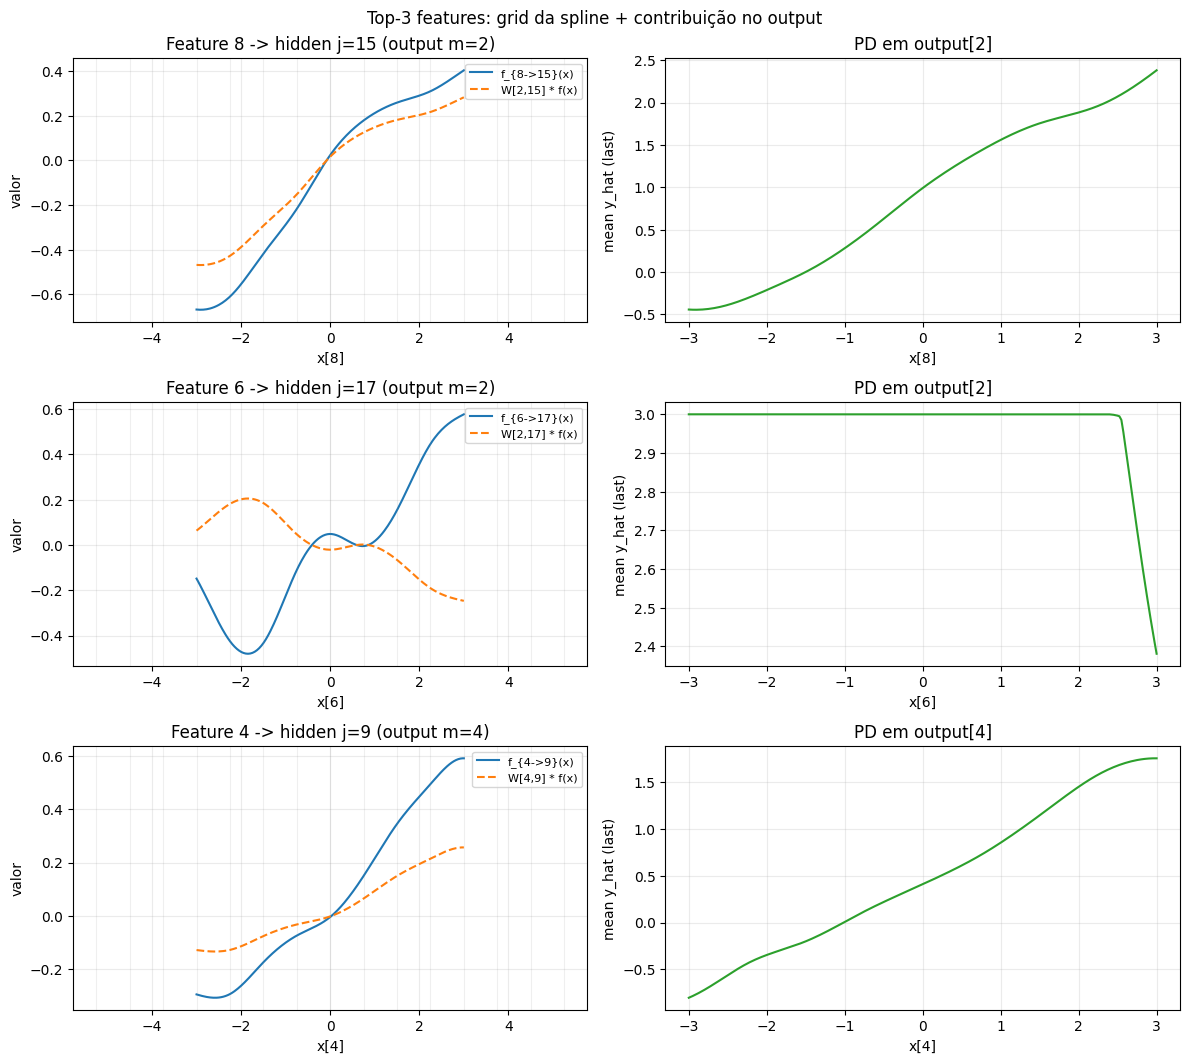

,feature_idx,hidden_j,output_m,w_mj,cell_score
0,8,15,2,0.700640,0.436401
1,6,17,2,-0.427325,0.373912
2,4,9,4,0.434835,0.345852


Figura salva em: /home/ferna/CPE727-2025-03/Seminarios/6 - RNN/seqKAN_results/fig_top3_features_grid_spline_impact.png
Resumo salvo em: /home/ferna/CPE727-2025-03/Seminarios/6 - RNN/seqKAN_results/explainability_v2_top3_feature_path_summary.csv


In [15]:
# STEP-PLOT-TOP3-FEATURES-GRID-AND-IMPACT (painel consolidado)
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from seqkan.kan.spline import coef2curve

TOPN = 3
N_GRID = 240
out_dir = '/home/ferna/CPE727-2025-03/Seminarios/6 - RNN/seqKAN_results'

seq_model = globals().get('seqkan_model', globals().get('model_tsdf_seqkanseq', None))
if seq_model is None:
    raise ValueError('seqKAN não encontrado em memória (seqkan_model/model_tsdf_seqkanseq).')

seq = seq_model.seqKAN
layer = seq.kan_cell.act_fun[0]
out_mod = seq.kan_out
if not isinstance(out_mod, torch.nn.Linear):
    raise ValueError(f'Este bloco assume kan_out Linear. Recebido: {type(out_mod).__name__}')

# escolhe TOPN features pelos maiores scores no top_edges_cell
p_cell = f"{out_dir}/explainability_v2_top_edges_cell.csv"
df_cell = pd.read_csv(p_cell).sort_values('score', ascending=False)
feat_order = []
for _, r in df_cell.iterrows():
    i = int(r['i_in'])
    if i not in feat_order:
        feat_order.append(i)
    if len(feat_order) >= TOPN:
        break
if len(feat_order) == 0:
    raise ValueError('Não encontrei features em explainability_v2_top_edges_cell.csv')

W = out_mod.weight.detach().cpu().numpy()  # (out_m, hidden_j)

# prepara batch para PD
has_eval = all(k in globals() for k in ['x_eval', 'ts_eval', 'm_eval'])
if has_eval:
    x_eval_pd = x_eval[:64].clone()
    ts_eval_pd = ts_eval[:64].clone()
    m_eval_pd = m_eval[:64].clone()
    dev = next(seq_model.parameters()).device
    x_eval_pd = x_eval_pd.to(dev)
    ts_eval_pd = ts_eval_pd.to(dev)
    m_eval_pd = m_eval_pd.to(dev)

fig, axes = plt.subplots(len(feat_order), 2 if has_eval else 1, figsize=(12, 3.6 * len(feat_order)))
if len(feat_order) == 1:
    axes = np.array([axes])
if axes.ndim == 1:
    axes = axes.reshape(len(feat_order), 1)

summary_rows = []

for row_idx, feature_idx in enumerate(feat_order):
    sub_feat = df_cell[df_cell['i_in'] == feature_idx].sort_values('score', ascending=False)
    j_out = int(sub_feat.iloc[0]['j_out'])
    output_m = int(np.argmax(np.abs(W[:, j_out])))
    w_mj = float(W[output_m, j_out])

    k = int(layer.k)
    grid_row = layer.grid[feature_idx].detach().cpu().numpy()
    x_min, x_max = float(grid_row[k]), float(grid_row[-k-1])
    x = np.linspace(x_min, x_max, int(N_GRID))

    x_t = torch.tensor(x, dtype=layer.grid.dtype, device=layer.grid.device).view(-1, 1)
    grid_t = layer.grid[feature_idx:feature_idx+1]
    coef_t = layer.coef[feature_idx:feature_idx+1, j_out:j_out+1]

    with torch.no_grad():
        y = coef2curve(x_t, grid_t, coef_t, layer.k)[:, 0, 0]
        if hasattr(layer, 'mask') and layer.mask is not None:
            y = y * layer.mask[feature_idx, j_out]
    y = y.detach().cpu().numpy()
    path_contrib = w_mj * y

    ax0 = axes[row_idx, 0]
    ax0.plot(x, y, label=f'f_{{{feature_idx}->{j_out}}}(x)')
    for gx in grid_row:
        ax0.axvline(float(gx), color='gray', alpha=0.12, linewidth=0.8)
    ax0.plot(x, path_contrib, '--', label=f'W[{output_m},{j_out}] * f(x)')
    ax0.set_title(f'Feature {feature_idx} -> hidden j={j_out} (output m={output_m})')
    ax0.set_xlabel(f'x[{feature_idx}]')
    ax0.set_ylabel('valor')
    ax0.grid(alpha=0.25)
    ax0.legend(fontsize=8)

    pd_out = None
    if has_eval:
        ys = []
        seq_model.eval()
        for v in x:
            xv = x_eval_pd.clone()
            xv[:, :, feature_idx] = float(v)
            with torch.no_grad():
                out = seq_model.forward(xv, timestamps=ts_eval_pd, return_x_hat=True, mask=m_eval_pd, test=True)
                yhat = out[3][:, -1, output_m].mean().item()
            ys.append(yhat)
        pd_out = np.array(ys, dtype=float)

        ax1 = axes[row_idx, 1]
        ax1.plot(x, pd_out, color='tab:green')
        ax1.set_title(f'PD em output[{output_m}]')
        ax1.set_xlabel(f'x[{feature_idx}]')
        ax1.set_ylabel('mean y_hat (last)')
        ax1.grid(alpha=0.25)

    summary_rows.append({
        'feature_idx': feature_idx,
        'hidden_j': j_out,
        'output_m': output_m,
        'w_mj': w_mj,
        'cell_score': float(sub_feat.iloc[0]['score']),
    })

fig.suptitle('Top-3 features: grid da spline + contribuição no output', fontsize=12)
fig.tight_layout()

png_path = f"{out_dir}/fig_top3_features_grid_spline_impact.png"
fig.savefig(png_path, dpi=180, bbox_inches='tight')
plt.show()

summary = pd.DataFrame(summary_rows)
display(summary)
summary.to_csv(f"{out_dir}/explainability_v2_top3_feature_path_summary.csv", index=False)
print('Figura salva em:', png_path)
print('Resumo salvo em:', f"{out_dir}/explainability_v2_top3_feature_path_summary.csv")



In [18]:
# STEP-RESUMO-3-FEATURES (pontos característicos + tamanho de efeito)
import numpy as np
import pandas as pd
from IPython.display import display

out_dir = '/home/ferna/CPE727-2025-03/Seminarios/6 - RNN/seqKAN_results'

# Arquivos gerados pela célula STEP-GERAR-3-FUNCOES-KAN
targets = [
    ('kan_function_i8_j15_m2_k3.csv', 8, 15, 2),
    ('kan_function_i6_j17_m2_k3.csv', 6, 17, 2),
    ('kan_function_i4_j9_m4_k3.csv', 4, 9, 4),
]

def _pick(df, x0):
    idx = (df['x'] - float(x0)).abs().idxmin()
    row = df.loc[idx]
    return float(row['x']), float(row['f_ij']), float(row['contrib_m'])

rows = []
for fn, i, j, m in targets:
    p = f"{out_dir}/{fn}"
    df = pd.read_csv(p)

    x_m3, f_m3, c_m3 = _pick(df, -3.0)
    x_0,  f_0,  c_0  = _pick(df,  0.0)
    x_p3, f_p3, c_p3 = _pick(df,  3.0)
    delta_c = c_p3 - c_m3

    rows.append({
        'feature_idx': i,
        'hidden_j': j,
        'output_m': m,
        'x(-3)': x_m3,
        'f(-3)': f_m3,
        'c(-3)': c_m3,
        'x(0)': x_0,
        'f(0)': f_0,
        'c(0)': c_0,
        'x(3)': x_p3,
        'f(3)': f_p3,
        'c(3)': c_p3,
        'delta_c_3_minus_m3': delta_c,
    })

summary = pd.DataFrame(rows)
display(summary)

# Texto curto pronto para slide
for _, r in summary.iterrows():
    print(
        f"[i={int(r['feature_idx'])} -> j={int(r['hidden_j'])} -> m={int(r['output_m'])}] "
        f"x=-3: f={r['f(-3)']:.3f}, c={r['c(-3)']:.3f} | "
        f"x~0: f={r['f(0)']:.3f}, c={r['c(0)']:.3f} | "
        f"x=3: f={r['f(3)']:.3f}, c={r['c(3)']:.3f} | "
        f"Delta c={r['delta_c_3_minus_m3']:.3f}"
    )

summary.to_csv(f"{out_dir}/kan_3funcoes_pontos_chave.csv", index=False)
print('Salvo:', f"{out_dir}/kan_3funcoes_pontos_chave.csv")
print('Nota: x está no espaço transformado (ex.: RobustScaler) e clampado em [-3, 3].')



,feature_idx,hidden_j,output_m,x(-3),f(-3),c(-3),x(0),f(0),c(0),x(3),f(3),c(3),delta_c_3_minus_m3
0,8,15,2,-3.0,-0.668827,-0.468607,-0.008596,0.021528,0.015084,3.0,0.404495,0.283405,0.752012
1,6,17,2,-3.0,-0.148395,0.063413,-0.008596,0.048722,-0.020820,3.0,0.577255,-0.246676,-0.310089
2,4,9,4,-3.0,-0.293761,-0.127738,-0.008596,-0.005077,-0.002208,3.0,0.590152,0.256619,0.384356


[i=8 -> j=15 -> m=2] x=-3: f=-0.669, c=-0.469 | x~0: f=0.022, c=0.015 | x=3: f=0.404, c=0.283 | Delta c=0.752
[i=6 -> j=17 -> m=2] x=-3: f=-0.148, c=0.063 | x~0: f=0.049, c=-0.021 | x=3: f=0.577, c=-0.247 | Delta c=-0.310
[i=4 -> j=9 -> m=4] x=-3: f=-0.294, c=-0.128 | x~0: f=-0.005, c=-0.002 | x=3: f=0.590, c=0.257 | Delta c=0.384
Salvo: /home/ferna/CPE727-2025-03/Seminarios/6 - RNN/seqKAN_results/kan_3funcoes_pontos_chave.csv
Nota: x está no espaço transformado (ex.: RobustScaler) e clampado em [-3, 3].
